In [1]:
# Import Required Libraries and Modules

import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Rescaling
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
# Load Training, Validation, and Test Datasets

# Define image dimensions and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load the validation dataset
valid_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load the test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 8000 files belonging to 2 classes.
Using 6400 files for training.
Found 8000 files belonging to 2 classes.
Using 1600 files for validation.
Found 2000 files belonging to 2 classes.


In [3]:
# Display the dataset class labels

class_names = train_ds.class_names
print(class_names)

['cats', 'dogs']


In [4]:
# Optimize Dataset Performance with Prefetching

# Enable automatic performance optimization
AUTOTUNE = tf.data.AUTOTUNE

# Prefetch batches to improve training efficiency
train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [5]:
# Define Data Augmentation Pipeline

# Create augmented variations of training images
data_augmentation = tf.keras.Sequential([

    # Randomly flip images horizontally
    tf.keras.layers.RandomFlip("horizontal"),

    # Randomly rotate images by a small angle
    tf.keras.layers.RandomRotation(0.1),

    # Randomly zoom into images
    tf.keras.layers.RandomZoom(0.1)
])

In [6]:
# Load and Freeze the Pretrained MobileNetV2 Model

# Load MobileNetV2 with ImageNet pretrained weights
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model for feature extraction
base_model.trainable = False

In [7]:
# Build the Classification Model

model = Sequential([

    # Apply data augmentation to training images
    data_augmentation,

    # Normalize pixel values to the range [-1, 1]
    Rescaling(1/127.5, offset=-1),

    # Extract features using pretrained MobileNetV2
    base_model,

    # Convert feature maps into a compact feature vector
    GlobalAveragePooling2D(),

    # Fully connected classification layer
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Binary classification output layer
    Dense(1, activation='sigmoid')
])

# Display the model architecture and parameter summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ ?                           │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Configure Training Callbacks

# Stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Save the model with the best validation accuracy
checkpoint = ModelCheckpoint(
    "best_transfer_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [9]:
# Compile the Model

# Configure loss function, optimizer, and evaluation metric
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [10]:
# Train the Transfer Learning Model

# Train the model using training data and validate on unseen data
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=15,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.9620 - loss: 0.1067 - val_accuracy: 0.9887 - val_loss: 0.0365
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9748 - loss: 0.0621 - val_accuracy: 0.9894 - val_loss: 0.0297
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9786 - loss: 0.0562 - val_accuracy: 0.9906 - val_loss: 0.0277
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9808 - loss: 0.0491 - val_accuracy: 0.9912 - val_loss: 0.0271
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.9795 - loss: 0.0482 - val_accuracy: 0.9900 - val_loss: 0.0234
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9823 - loss: 0.0461 - val_accuracy: 0.9906 - val_loss: 0.0264
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.9845 - loss: 0.0412 - val_accuracy: 0.9900 - val_loss: 0.0264
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.9858 - loss: 0.0364 - val_accu

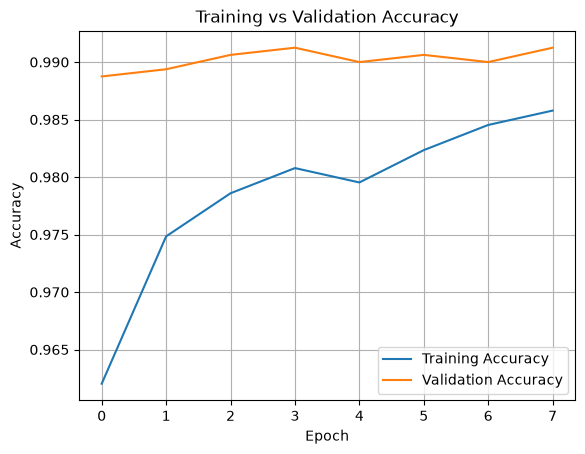

In [11]:
# Visualize Model Accuracy

# Plot training and validation accuracy across epochs
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

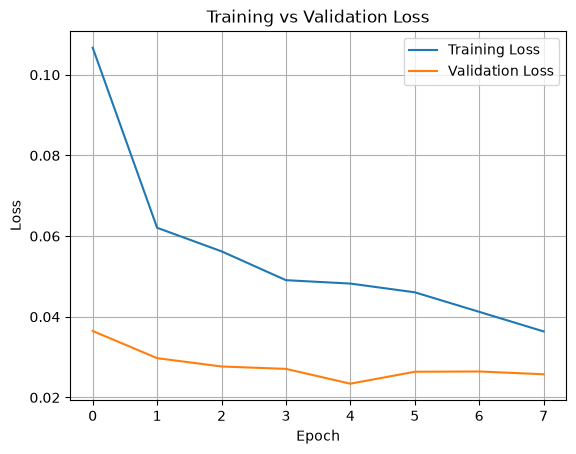

In [12]:
# Visualize Model Loss

# Plot training and validation loss across epochs
plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Load the Best Saved Model

model = tf.keras.models.load_model(
    "best_transfer_model.keras"
)

In [14]:
# Evaluate Model Performance on Test Data

test_loss, test_acc = model.evaluate(test_ds)

print("Loss:", test_loss)
print("Test Accuracy:", test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 797ms/step - accuracy: 0.9895 - loss: 0.0336
Loss: 0.03359875828027725
Test Accuracy: 0.9894999861717224


In [20]:
# Get Predictions on Test Set

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = (predictions > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

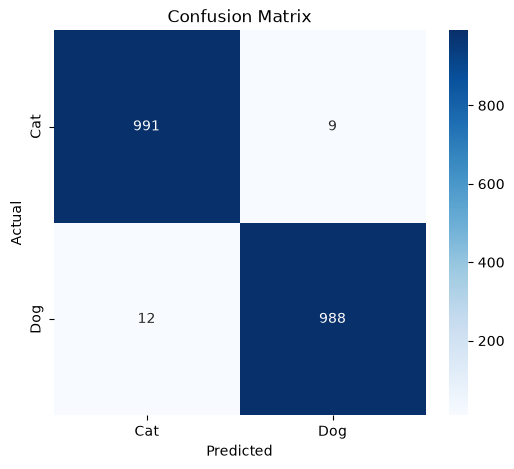

In [21]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cat','Dog'],
    yticklabels=['Cat','Dog']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=['Cat','Dog']
    )
)

              precision    recall  f1-score   support

         Cat       0.99      0.99      0.99      1000
         Dog       0.99      0.99      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



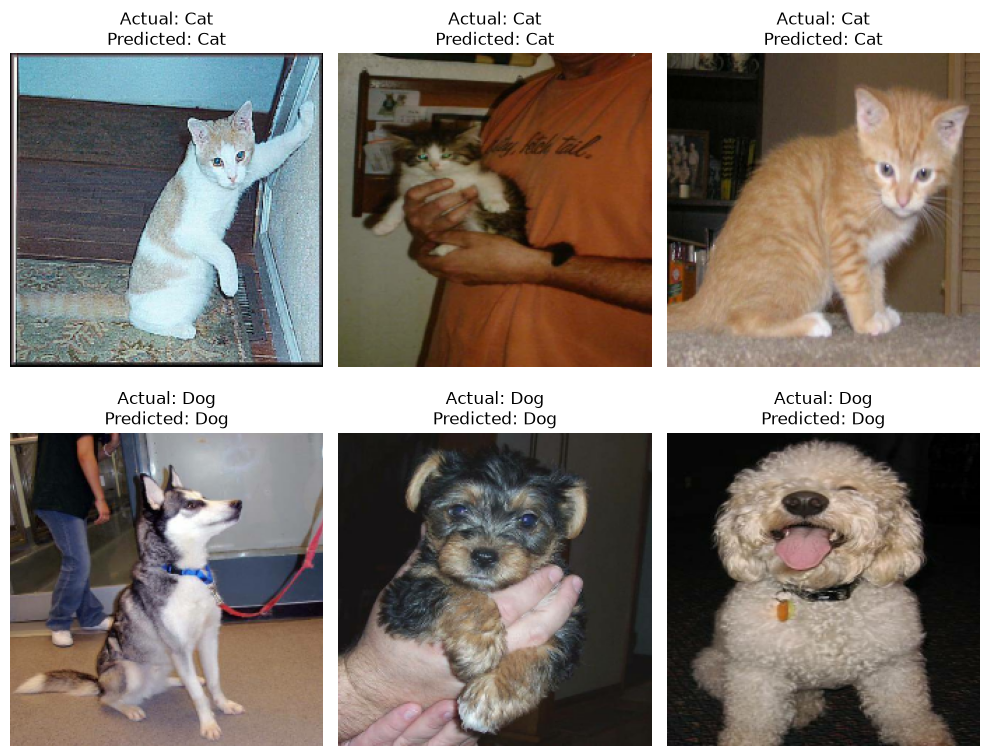

In [31]:
# Display Sample Test Predictions

class_names = ['Cat', 'Dog']

cat_samples = []
dog_samples = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    for i in range(len(images)):

        actual = int(labels[i].numpy())
        pred = int(predictions[i][0] > 0.5)

        sample = (
            images[i].numpy().astype("uint8"),
            actual,
            pred
        )

        if actual == 0 and len(cat_samples) < 3:
            cat_samples.append(sample)

        elif actual == 1 and len(dog_samples) < 3:
            dog_samples.append(sample)

        if len(cat_samples) == 3 and len(dog_samples) == 3:
            break

    if len(cat_samples) == 3 and len(dog_samples) == 3:
        break

# Combine samples
samples = cat_samples + dog_samples

# Display images
plt.figure(figsize=(10, 8))

for idx, (img, actual, pred) in enumerate(samples):

    plt.subplot(2, 3, idx + 1)

    plt.imshow(img)

    plt.title(
        f"Actual: {class_names[actual]}\n"
        f"Predicted: {class_names[pred]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Conclusion

A transfer learning-based image classification model was developed using MobileNetV2 to distinguish between cats and dogs. Data augmentation techniques were applied to improve the model's generalization ability and reduce overfitting.

The model achieved a **Test Accuracy of 98.95%** with a **Test Loss of 0.0336**, demonstrating excellent performance on unseen test data.

## Performance Summary

Test Accuracy | 98.95% 

Test Loss | 0.0336 

Precision | 0.99 

Recall | 0.99 

F1-Score | 0.99

## Confusion Matrix Analysis

The confusion matrix indicates that the model correctly classified:

- 991 out of 1000 cat images
- 988 out of 1000 dog images

Only **21 out of 2000 test images** were misclassified, resulting in a highly accurate classification model.

## Training Analysis

- Training accuracy improved steadily throughout the training process.
- Validation accuracy remained consistently high.
- Training and validation losses decreased over epochs.
- No significant signs of overfitting were observed.
- Data augmentation contributed to better generalization on unseen data.

## Final Outcome

The MobileNetV2 transfer learning model successfully learned discriminative features for cat and dog classification. The high accuracy, precision, recall, and F1-score demonstrate the effectiveness of transfer learning for image classification tasks.

This project highlights the application of Convolutional Neural Networks (CNNs), Transfer Learning, Data Augmentation, and Performance Evaluation techniques in solving a real-world image classification problem.